In [1]:
import ast

# ============================================================
# FILES
# ============================================================

files = [
    "reglas_abac.txt",
    "reglas_abac-hc.txt",
    "reglas_abac_iot.txt",
    "reglas_abac_karimi.txt",
    "reglas_abac_karimi_hc.txt",
    "reglas_abac_karimi_iot.txt",
]

labels = [
    r"$AMZ_{D}$",
    r"$HC_{D}$",
    r"$Iot_{D}$",
    r"$AMZ_{K}$",
    r"$HC_{K}$",
    r"$Iot_{K}$",
]

# ============================================================
# COMPUTE WSC
# ============================================================

def compute_wsc(filepath):

    wsc = 0

    with open(filepath, "r", encoding="utf-8") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            try:

                data = ast.literal_eval(line)

                attributes = data[1]

                # WSC:
                # Sum of all attribute-value tuples
                wsc += len(attributes)

            except Exception as e:

                print(f"Error processing {filepath}")
                print(e)

    return wsc

# ============================================================
# COMPUTE RESULTS
# ============================================================

results = []

for file, label in zip(files, labels):

    wsc = compute_wsc(file)

    results.append((label, wsc))

# ============================================================
# GENERATE LATEX TABLE
# ============================================================

print(r"\begin{table}[ht]")
print(r"\centering")
print(r"\caption{Weighted Structural Complexity (WSC) for each dataset.}")
print(r"\label{tab:wsc}")
print(r"\begin{tabular}{lc}")
print(r"\hline")
print(r"Dataset & WSC \\")
print(r"\hline")

for label, wsc in results:

    print(
        f"{label} & {wsc} \\\\"
    )

print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")

\begin{table}[ht]
\centering
\caption{Weighted Structural Complexity (WSC) for each dataset.}
\label{tab:wsc}
\begin{tabular}{lc}
\hline
Dataset & WSC \\
\hline
$AMZ_{D}$ & 320 \\
$HC_{D}$ & 355 \\
$Iot_{D}$ & 459 \\
$AMZ_{K}$ & 65 \\
$HC_{K}$ & 70 \\
$Iot_{K}$ & 89 \\
\hline
\end{tabular}
\end{table}


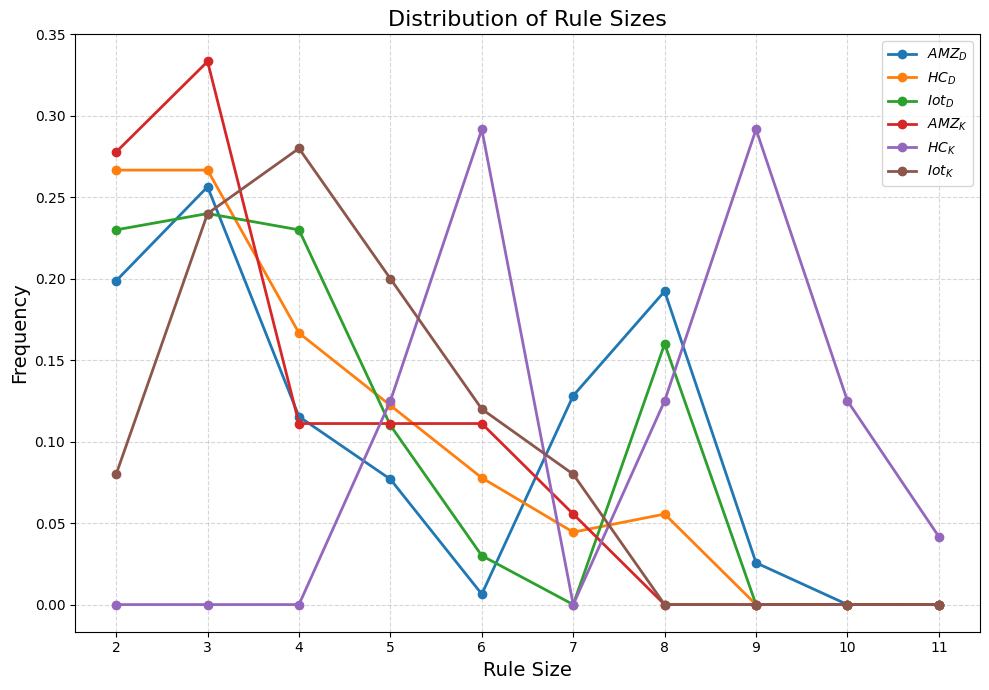

In [9]:
import os
import ast
from collections import Counter
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURACIÓN
# ============================================================

# Coloca aquí las rutas de tus 6 archivos
files = [
    "reglas_abac.txt",
    "reglas_abac-hc.txt",
    "reglas_abac_iot.txt",
    "reglas_abac_karimi.txt",
    "reglas_abac_karimi_hc.txt",
    "reglas_abac_karimi_iot.txt",
]

# Etiquetas para la leyenda
labels = [
    r"$AMZ_{D}$",
    r"$HC_{D}$",
    r"$Iot_{D}$",
    r"$AMZ_{K}$",
    r"$HC_{K}$",
    r"$Iot_{K}$",
]

# ============================================================
# FUNCIÓN PARA OBTENER EL TAMAÑO DE CADA REGLA
# ============================================================

def extract_rule_sizes(filepath):
    """
    Extracts the size of each rule.
    Rule size = number of attribute-value pairs
    in the second list.
    """

    rule_sizes = []

    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:

        line = line.strip()

        if not line:
            continue

        try:
            data = ast.literal_eval(line)

            # Example format:
            # [["id_com", "0"], [["role", 10], ["type", 201]]]

            attributes = data[1]

            rule_size = len(attributes)

            rule_sizes.append(rule_size)

        except Exception as e:
            print(f"Error processing line in {filepath}")
            print(line)
            print(e)

    return rule_sizes

# ============================================================
# PROCESS FILES
# ============================================================

all_distributions = []

for filepath in files:

    sizes = extract_rule_sizes(filepath)

    distribution = Counter(sizes)

    total_rules = sum(distribution.values())

    # Normalize frequencies
    normalized_distribution = {
        size: freq / total_rules
        for size, freq in distribution.items()
    }

    all_distributions.append(normalized_distribution)

# ============================================================
# GLOBAL RANGE OF RULE SIZES
# ============================================================

all_sizes = set()

for dist in all_distributions:
    all_sizes.update(dist.keys())

all_sizes = sorted(all_sizes)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 7))

for dist, label in zip(all_distributions, labels):

    x = all_sizes
    y = [dist.get(size, 0) for size in x]

    plt.plot(
        x,
        y,
        marker='o',
        linewidth=2,
        label=label
    )

# ============================================================
# STYLE
# ============================================================

plt.xlabel("Rule Size", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.title(
    "Distribution of Rule Sizes",
    fontsize=16
)

plt.xticks(all_sizes)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.legend()

plt.tight_layout()

# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    "normalized_rule_size_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

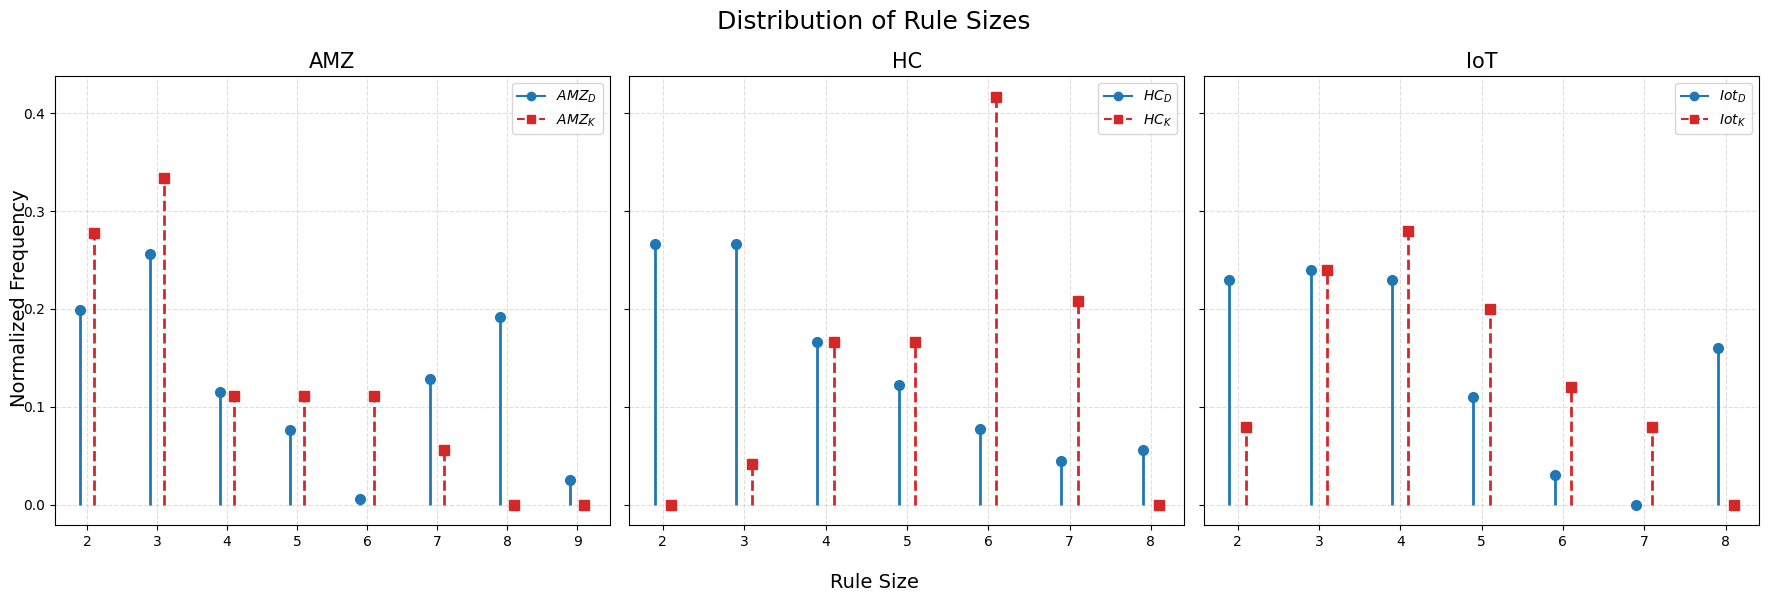

In [24]:
import ast
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# FILES
# ============================================================

files = [
    "reglas_abac.txt",
    "reglas_abac-hc.txt",
    "reglas_abac_iot.txt",
    "reglas_abac_karimi.txt",
    "reglas_abac_karimi_hc.txt",
    "reglas_abac_karimi_iot.txt",
]
files = [
    "reglas_abac_2.txt",
    "reglas_abac_hc_2.txt",
    "reglas_abac_iot_2.txt",
    "reglas_abac_karimi_2.txt",
    "reglas_abac_karimi_hc_2.txt",
    "reglas_abac_karimi_iot_2.txt",
]

labels = [
    r"$AMZ_{D}$",
    r"$HC_{D}$",
    r"$Iot_{D}$",
    r"$AMZ_{K}$",
    r"$HC_{K}$",
    r"$Iot_{K}$",
]

# ============================================================
# FUNCTION TO EXTRACT RULE SIZES
# ============================================================

def extract_rule_sizes(filepath):

    rule_sizes = []

    with open(filepath, "r", encoding="utf-8") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            try:

                data = ast.literal_eval(line)

                attributes = data[1]

                rule_sizes.append(len(attributes))

            except Exception as e:

                print(f"Error processing {filepath}")
                print(e)

    return rule_sizes

# ============================================================
# PROCESS FILES
# ============================================================

all_distributions = []

for filepath in files:

    sizes = extract_rule_sizes(filepath)

    distribution = Counter(sizes)

    total_rules = sum(distribution.values())

    # Normalized frequencies
    normalized_distribution = {
        size: freq / total_rules
        for size, freq in distribution.items()
    }

    all_distributions.append(normalized_distribution)

# ============================================================
# SUBFIGURE GROUPS
# ============================================================

groups = [
    (0, 3, "AMZ"),
    (1, 4, "HC"),
    (2, 5, "IoT")
]

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    sharey=True
)

# ============================================================
# PLOT
# ============================================================

for ax, (idx_d, idx_k, title) in zip(axes, groups):

    dist_d = all_distributions[idx_d]
    dist_k = all_distributions[idx_k]

    # Global x-axis for this subplot
    all_sizes = sorted(
        set(dist_d.keys()).union(dist_k.keys())
    )

    y_d = [
        dist_d.get(size, 0)
        for size in all_sizes
    ]

    y_k = [
        dist_k.get(size, 0)
        for size in all_sizes
    ]

    x = np.arange(len(all_sizes))

    # ========================================================
    # STEM PLOT FOR D
    # ========================================================

    markerline1, stemlines1, baseline1 = ax.stem(
        x - 0.1,
        y_d,
        linefmt='tab:blue',
        markerfmt='o',
        basefmt=' '
    )

    plt.setp(
        stemlines1,
        linewidth=2,
        color='tab:blue'
    )

    plt.setp(
        markerline1,
        markersize=7,
        markerfacecolor='tab:blue'
    )

    # ========================================================
    # STEM PLOT FOR K
    # ========================================================

    markerline2, stemlines2, baseline2 = ax.stem(
        x + 0.1,
        y_k,
        linefmt='tab:red',
        markerfmt='s',
        basefmt=' '
    )

    plt.setp(
        stemlines2,
        linewidth=2,
        color='tab:red',
        linestyle='--'
    )

    plt.setp(
        markerline2,
        markersize=7,
        markerfacecolor='tab:red'
    )

    # ========================================================
    # AXES
    # ========================================================

    ax.set_xticks(x)

    ax.set_xticklabels(all_sizes)

    ax.set_title(
        title,
        fontsize=15
    )

    ax.grid(
        True,
        linestyle='--',
        alpha=0.4
    )

    # ========================================================
    # LEGEND
    # ========================================================

    ax.plot(
        [],
        [],
        marker='o',
        linestyle='-',
        markersize=6,
        color='tab:blue',
        label=labels[idx_d]
    )

    ax.plot(
        [],
        [],
        marker='s',
        linestyle='--',
        color='tab:red',
        markersize=6,
        label=labels[idx_k]
    )

    ax.legend()

# ============================================================
# GLOBAL LABELS
# ============================================================

fig.suptitle(
    "Distribution of Rule Sizes",
    fontsize=18
)

fig.supxlabel(
    "Rule Size",
    fontsize=14
)

fig.supylabel(
    "Normalized Frequency",
    fontsize=14
)

plt.tight_layout()

# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    "rule_size_subfigures.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
import ast
import numpy as np

# ============================================================
# FILES
# ============================================================

files = [
    "reglas_abac.txt",
    "reglas_abac-hc.txt",
    "reglas_abac_iot.txt",
    "reglas_abac_karimi.txt",
    "reglas_abac_karimi_hc.txt",
    "reglas_abac_karimi_iot.txt",
]

labels = [
    r"$AMZ_{D}$",
    r"$HC_{D}$",
    r"$Iot_{D}$",
    r"$AMZ_{K}$",
    r"$HC_{K}$",
    r"$Iot_{K}$",
]

# ============================================================
# FUNCTION
# ============================================================

def extract_rule_sizes(filepath):

    sizes = []

    with open(filepath, "r", encoding="utf-8") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            try:
                data = ast.literal_eval(line)

                attributes = data[1]

                sizes.append(len(attributes))

            except Exception as e:

                print(f"Error in {filepath}")
                print(e)

    return np.array(sizes)

# ============================================================
# GENERATE LATEX TABLE ROWS
# ============================================================

for file, label in zip(files, labels):

    sizes = extract_rule_sizes(file)

    mean_val = np.mean(sizes)
    var_val = np.var(sizes)
    std_val = np.std(sizes)

    min_val = np.min(sizes)
    max_val = np.max(sizes)

    print(
        f"{label} & "
        f"{mean_val:.2f} & "
        f"{var_val:.2f} & "
        f"{std_val:.2f} & "
        f"{min_val} & "
        f"{max_val} \\\\"
    )

$AMZ_{D}$ & 4.72 & 5.51 & 2.35 & 2 & 9 \\
$HC_{D}$ & 3.83 & 3.03 & 1.74 & 2 & 8 \\
$Iot_{D}$ & 4.11 & 3.94 & 1.98 & 2 & 8 \\
$AMZ_{K}$ & 3.61 & 2.35 & 1.53 & 2 & 7 \\
$HC_{K}$ & 7.71 & 3.37 & 1.84 & 5 & 11 \\
$Iot_{K}$ & 4.28 & 1.88 & 1.37 & 2 & 7 \\


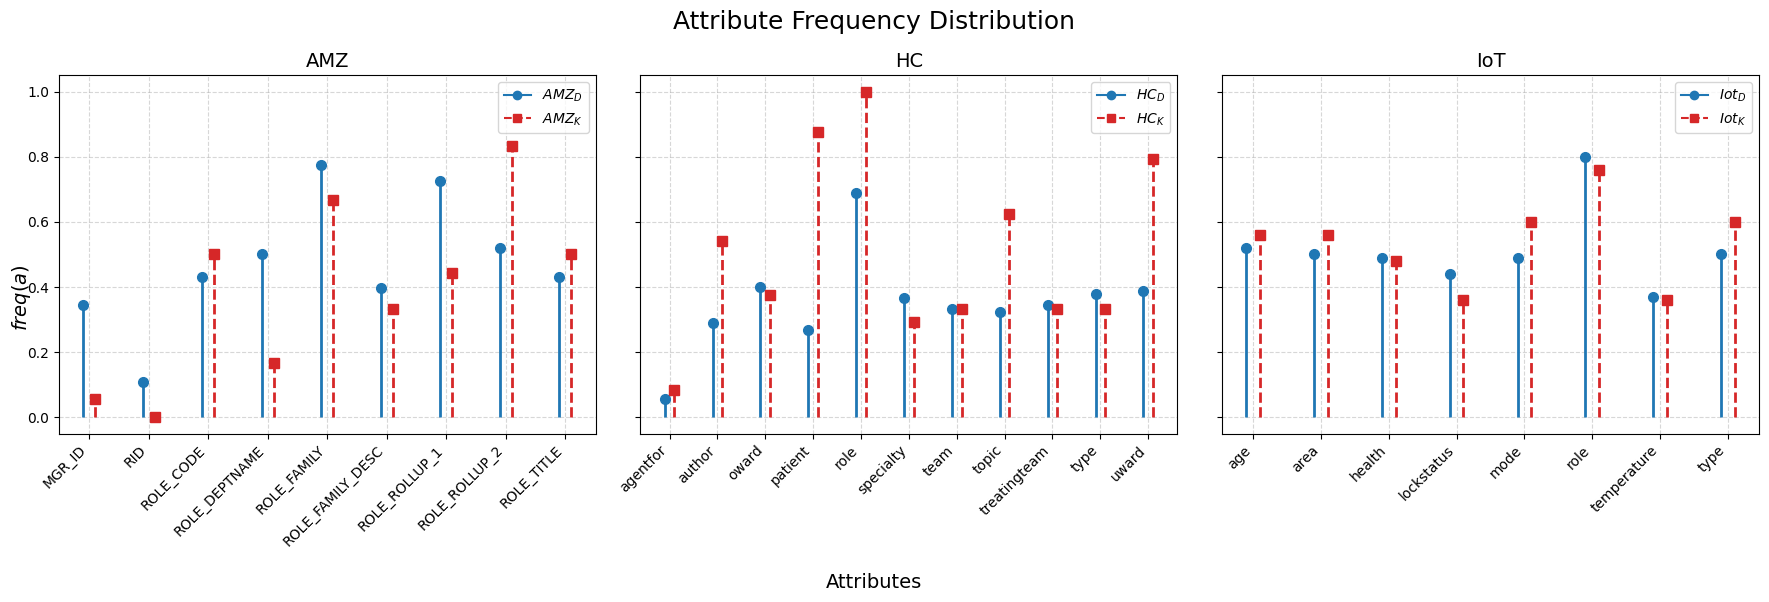

In [23]:
import ast
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# FILES
# ============================================================

files = [
    "reglas_abac.txt",
    "reglas_abac-hc.txt",
    "reglas_abac_iot.txt",
    "reglas_abac_karimi.txt",
    "reglas_abac_karimi_hc.txt",
    "reglas_abac_karimi_iot.txt",
]
files = [
    "reglas_abac_2.txt",
    "reglas_abac_hc_2.txt",
    "reglas_abac_iot_2.txt",
    "reglas_abac_karimi_2.txt",
    "reglas_abac_karimi_hc_2.txt",
    "reglas_abac_karimi_iot_2.txt",
]

labels = [
    r"$AMZ_{D}$",
    r"$HC_{D}$",
    r"$Iot_{D}$",
    r"$AMZ_{K}$",
    r"$HC_{K}$",
    r"$Iot_{K}$",
]

# ============================================================
# FUNCTION TO COMPUTE ATTRIBUTE FREQUENCY
# ============================================================

def compute_attribute_frequency(filepath):

    attribute_counter = Counter()
    total_rules = 0

    with open(filepath, "r", encoding="utf-8") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            try:

                data = ast.literal_eval(line)

                attributes = data[1]

                # Unique attributes inside each rule
                attrs_in_rule = set()

                for attr, value in attributes:

                    attrs_in_rule.add(attr)

                for attr in attrs_in_rule:

                    attribute_counter[attr] += 1

                total_rules += 1

            except Exception as e:

                print(f"Error processing {filepath}")
                print(e)

    # ========================================================
    # NORMALIZED FREQUENCY
    # ========================================================

    frequencies = {
        attr: count / total_rules
        for attr, count in attribute_counter.items()
    }

    return frequencies

# ============================================================
# COMPUTE FREQUENCIES
# ============================================================

all_frequencies = []

for file in files:

    freq = compute_attribute_frequency(file)

    all_frequencies.append(freq)

# ============================================================
# GROUPS FOR SUBFIGURES
# ============================================================

groups = [
    (0, 3, "AMZ"),
    (1, 4, "HC"),
    (2, 5, "IoT")
]

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    sharey=True
)

# ============================================================
# PLOT
# ============================================================

for ax, (idx_d, idx_k, title) in zip(axes, groups):

    freq_d = all_frequencies[idx_d]
    freq_k = all_frequencies[idx_k]

    # ========================================================
    # UNION OF ATTRIBUTES
    # ========================================================

    attributes = sorted(
        set(freq_d.keys()).union(freq_k.keys())
    )

    x = np.arange(len(attributes))

    y_d = [
        freq_d.get(attr, 0)
        for attr in attributes
    ]

    y_k = [
        freq_k.get(attr, 0)
        for attr in attributes
    ]

    # ========================================================
    # STEM PLOT FOR D
    # ========================================================

    markerline1, stemlines1, baseline1 = ax.stem(
        x - 0.1,
        y_d,
        linefmt='tab:blue',
        markerfmt='o',
        basefmt=' '
    )

    plt.setp(
        stemlines1,
        linewidth=2,
        color='tab:blue'
    )

    plt.setp(
        markerline1,
        markersize=7,
        markerfacecolor='tab:blue',
        markeredgecolor='tab:blue'
    )

    # ========================================================
    # STEM PLOT FOR K
    # ========================================================

    markerline2, stemlines2, baseline2 = ax.stem(
        x + 0.1,
        y_k,
        linefmt='tab:red',
        markerfmt='s',
        basefmt=' '
    )

    plt.setp(
        stemlines2,
        linewidth=2,
        color='tab:red',
        linestyle='--'
    )

    plt.setp(
        markerline2,
        markersize=7,
        markerfacecolor='tab:red',
        markeredgecolor='tab:red'
    )

    # ========================================================
    # AXES
    # ========================================================

    ax.set_title(
        title,
        fontsize=14
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        attributes,
        rotation=45,
        ha='right'
    )

    ax.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

    # ========================================================
    # LEGEND
    # ========================================================

    ax.plot(
        [],
        [],
        marker='o',
        markersize=6,
        linestyle='-',
        color='tab:blue',
        label=labels[idx_d]
    )

    ax.plot(
        [],
        [],
        marker='s',
        markersize=6,
        linestyle='--',
        color='tab:red',
        label=labels[idx_k]
    )

    ax.legend()

# ============================================================
# GLOBAL LABELS
# ============================================================

fig.suptitle(
    "Attribute Frequency Distribution",
    fontsize=18
)

fig.supxlabel(
    "Attributes",
    fontsize=14
)

fig.supylabel(
    r"$freq(a)$",
    fontsize=14
)

plt.tight_layout()

# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    "attribute_frequency_subfigures.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

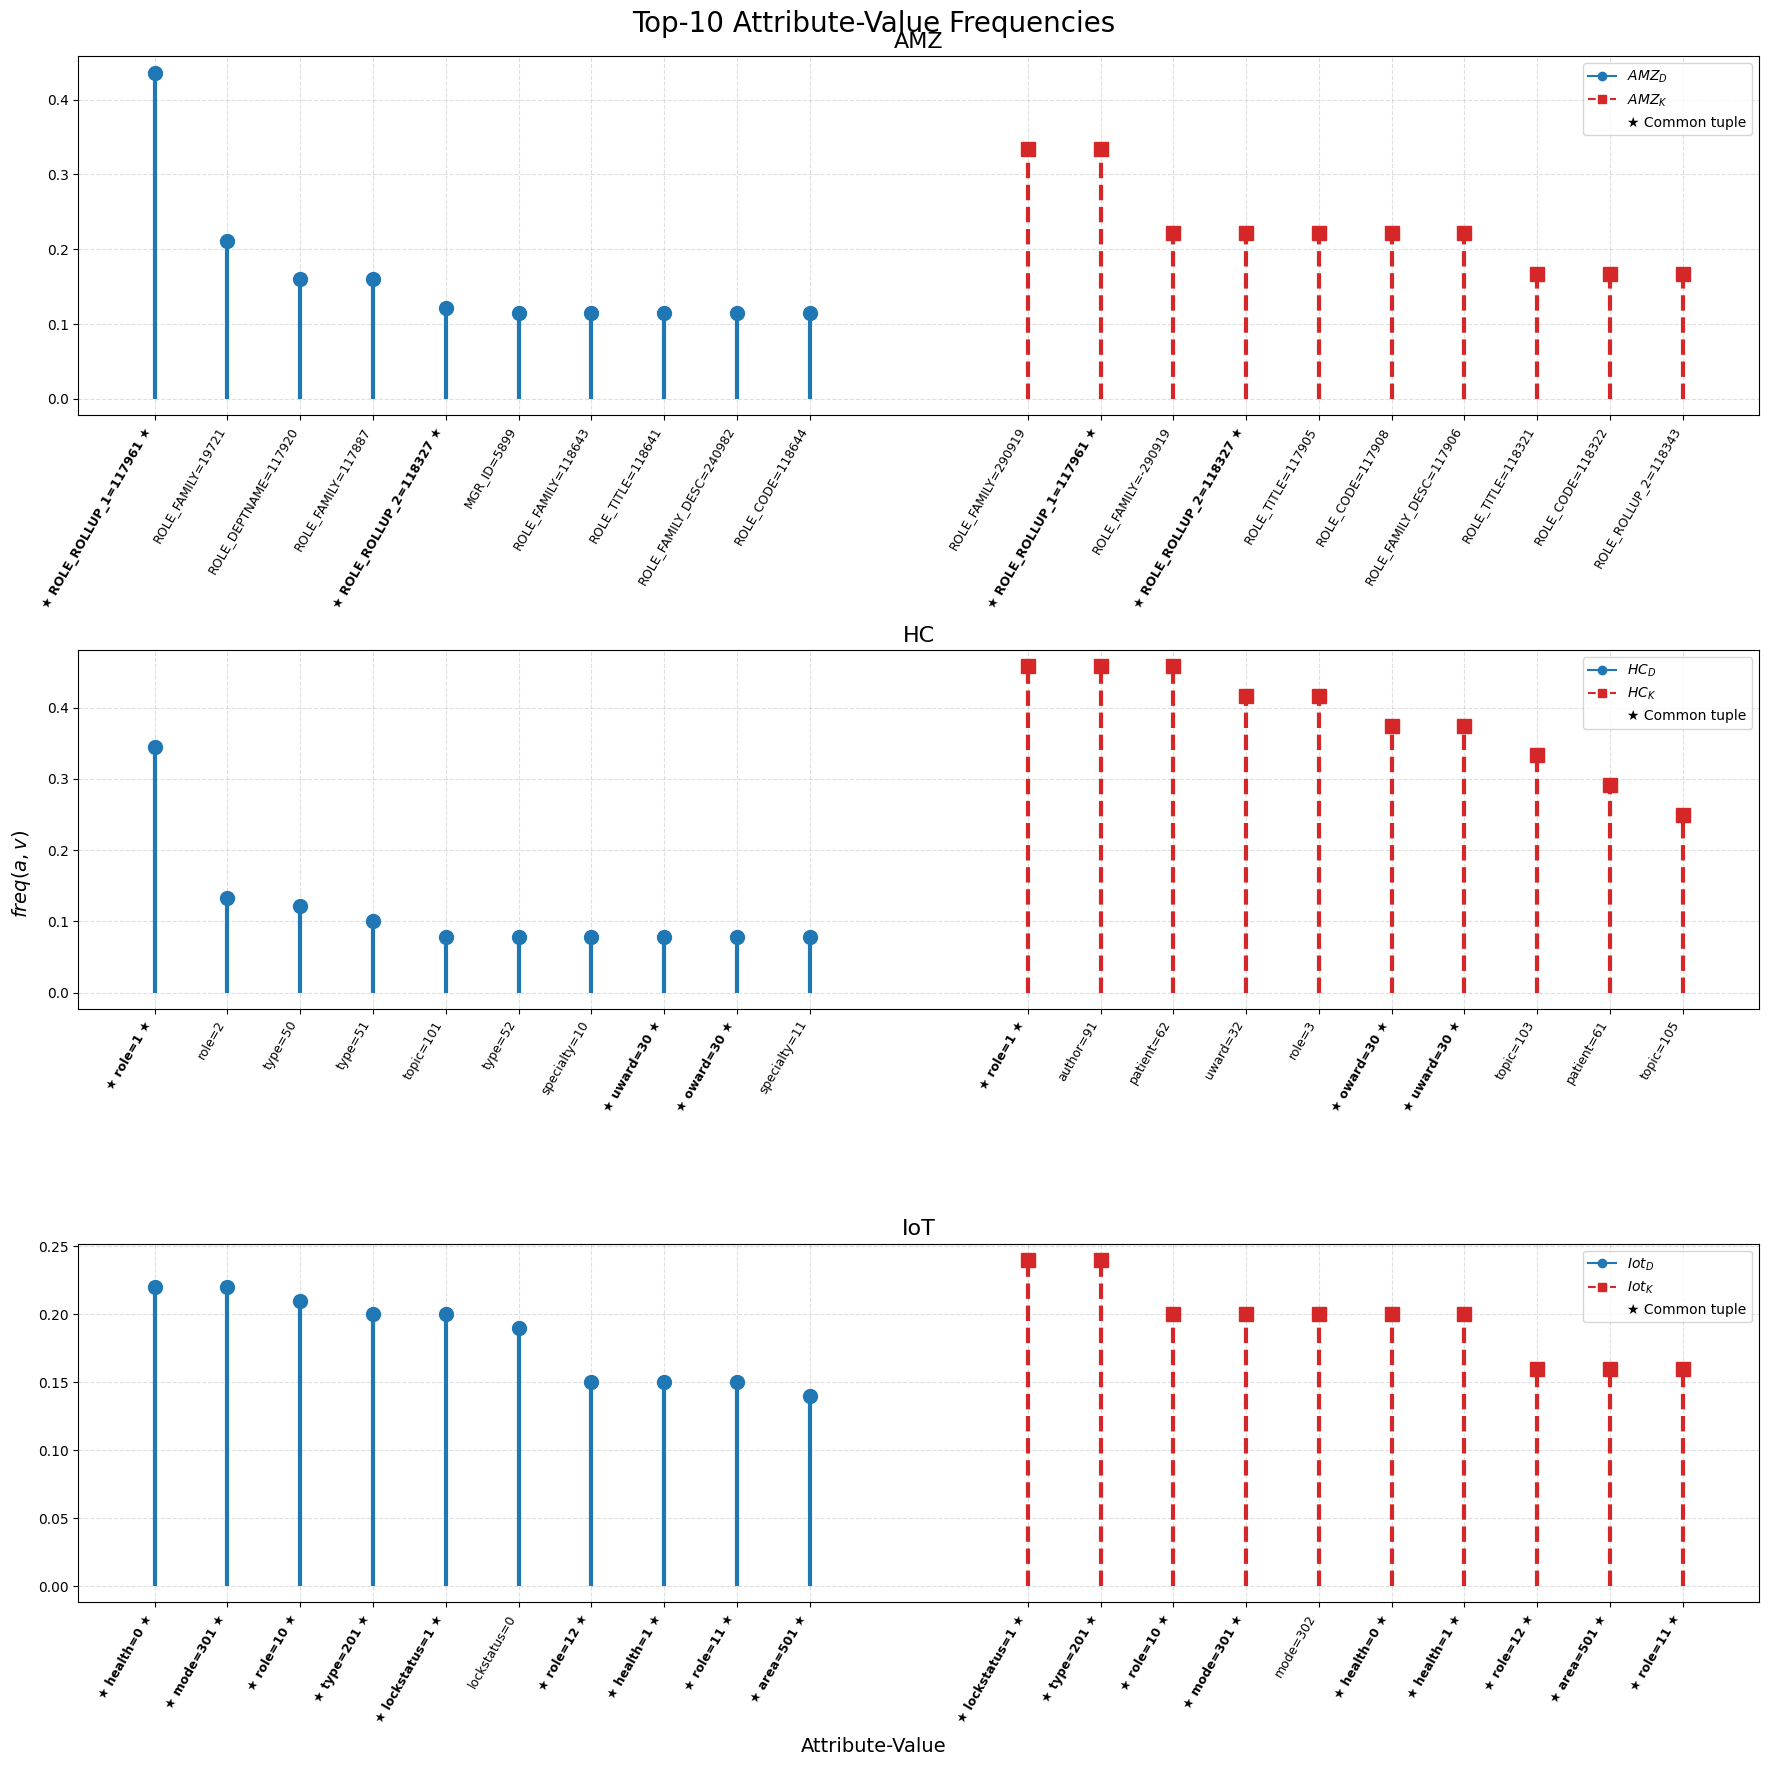

In [20]:
import ast
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# FILES
# ============================================================

files = [
    "reglas_abac_2.txt",
    "reglas_abac_hc_2.txt",
    "reglas_abac_iot_2.txt",
    "reglas_abac_karimi_2.txt",
    "reglas_abac_karimi_hc_2.txt",
    "reglas_abac_karimi_iot_2.txt",
]

labels = [
    r"$AMZ_{D}$",
    r"$HC_{D}$",
    r"$Iot_{D}$",
    r"$AMZ_{K}$",
    r"$HC_{K}$",
    r"$Iot_{K}$",
]

# ============================================================
# FUNCTION
# ============================================================

def compute_attribute_value_frequency(filepath):

    av_counter = Counter()
    total_rules = 0

    with open(filepath, "r", encoding="utf-8") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            try:

                data = ast.literal_eval(line)

                attributes = data[1]

                unique_pairs = set()

                for attr, value in attributes:

                    unique_pairs.add((attr, value))

                for pair in unique_pairs:

                    av_counter[pair] += 1

                total_rules += 1

            except Exception as e:

                print(f"Error processing {filepath}")
                print(e)

    frequencies = {
        pair: count / total_rules
        for pair, count in av_counter.items()
    }

    return frequencies

# ============================================================
# COMPUTE FREQUENCIES
# ============================================================

all_frequencies = []

for file in files:

    freq = compute_attribute_value_frequency(file)

    all_frequencies.append(freq)

# ============================================================
# GROUPS
# ============================================================

groups = [
    (0, 3, "AMZ"),
    (1, 4, "HC"),
    (2, 5, "IoT")
]

TOP_K = 10

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(18, 18)
)

for ax, (idx_d, idx_k, title) in zip(axes, groups):

    freq_d = all_frequencies[idx_d]
    freq_k = all_frequencies[idx_k]

    # ========================================================
    # TOP 10 MOST FREQUENT PAIRS
    # ========================================================

    top_d = sorted(
        freq_d.items(),
        key=lambda x: x[1],
        reverse=True
    )[:TOP_K]

    top_k = sorted(
        freq_k.items(),
        key=lambda x: x[1],
        reverse=True
    )[:TOP_K]

    # ========================================================
    # COMMON PAIRS
    # ========================================================

    common_pairs = set(
        pair for pair, _ in top_d
    ).intersection(
        set(pair for pair, _ in top_k)
    )

    # ========================================================
    # VALUES
    # ========================================================

    y_d = [v for _, v in top_d]
    y_k = [v for _, v in top_k]

    # ========================================================
    # LABELS
    # ========================================================

    labels_d = [
        f"{a}={v}"
        for (a, v), _ in top_d
    ]

    labels_k = [
        f"{a}={v}"
        for (a, v), _ in top_k
    ]

    # ========================================================
    # POSITIONS
    # ========================================================

    x_d = np.arange(TOP_K)

    offset = TOP_K + 2

    x_k = np.arange(TOP_K) + offset

    # ========================================================
    # STEM PLOT FOR D
    # ========================================================

    markerline1, stemlines1, baseline1 = ax.stem(
        x_d,
        y_d,
        linefmt='tab:blue',
        markerfmt='o',
        basefmt=' '
    )

    plt.setp(
        stemlines1,
        linewidth=3,
        color='tab:blue'
    )

    plt.setp(
        markerline1,
        markersize=10,
        markerfacecolor='tab:blue',
        markeredgecolor='tab:blue'
    )

    # ========================================================
    # STEM PLOT FOR K
    # ========================================================

    markerline2, stemlines2, baseline2 = ax.stem(
        x_k,
        y_k,
        linefmt='tab:red',
        markerfmt='s',
        basefmt=' '
    )

    plt.setp(
        stemlines2,
        linewidth=3,
        color='tab:red',
        linestyle='--'
    )

    plt.setp(
        markerline2,
        markersize=10,
        markerfacecolor='tab:red',
        markeredgecolor='tab:red'
    )

    # ========================================================
    # X AXIS
    # ========================================================

    xticks = list(x_d) + list(x_k)

    xticklabels = labels_d + labels_k

    ax.set_xticks(xticks)

    tick_objects = ax.set_xticklabels(
        xticklabels,
        rotation=60,
        ha='right',
        fontsize=9
    )

    # ========================================================
    # COLOR REPEATED PAIRS IN GREEN
    # ========================================================

    all_pairs = [
        pair for pair, _ in top_d
    ] + [
        pair for pair, _ in top_k
    ]

    for tick, pair in zip(tick_objects, all_pairs):

        if pair in common_pairs:

            tick.set_text("★ " + tick.get_text()+ " ★")   # add star
            tick.set_fontweight('bold')             # bold
            #tick.set_color('green')                 # no dependence on color

    ax.set_xticklabels(
    tick_objects,
    rotation=60,
    ha='right',
    fontsize=9
)
    # ========================================================
    # TITLE
    # ========================================================

    ax.set_title(
        title,
        fontsize=16
    )

    # ========================================================
    # GRID
    # ========================================================

    ax.grid(
        True,
        linestyle='--',
        alpha=0.4
    )

    # ========================================================
    # LEGEND
    # ========================================================

    ax.plot(
        [],
        [],
        marker='o',
        linestyle='-',
        color='tab:blue',
        markersize=6,
        label=labels[idx_d]
    )

    ax.plot(
        [],
        [],
        marker='s',
        linestyle='--',
        color='tab:red',
        markersize=6,
        label=labels[idx_k]
    )

    ax.plot(
        [],
        [],
        linestyle='None',
        label='★ Common tuple'
    )

    ax.legend()

# ============================================================
# GLOBAL LABELS
# ============================================================

fig.suptitle(
    "Top-10 Attribute-Value Frequencies",
    fontsize=20
)

fig.supxlabel(
    "Attribute-Value",
    fontsize=14
)

fig.supylabel(
    r"$freq(a,v)$",
    fontsize=14
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "top10_attribute_value_pair_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


Processing reglas_abac.txt...
Processing reglas_abac-hc.txt...
Processing reglas_abac_iot.txt...
Processing reglas_abac_karimi.txt...
Processing reglas_abac_karimi_hc.txt...
Processing reglas_abac_karimi_iot.txt...


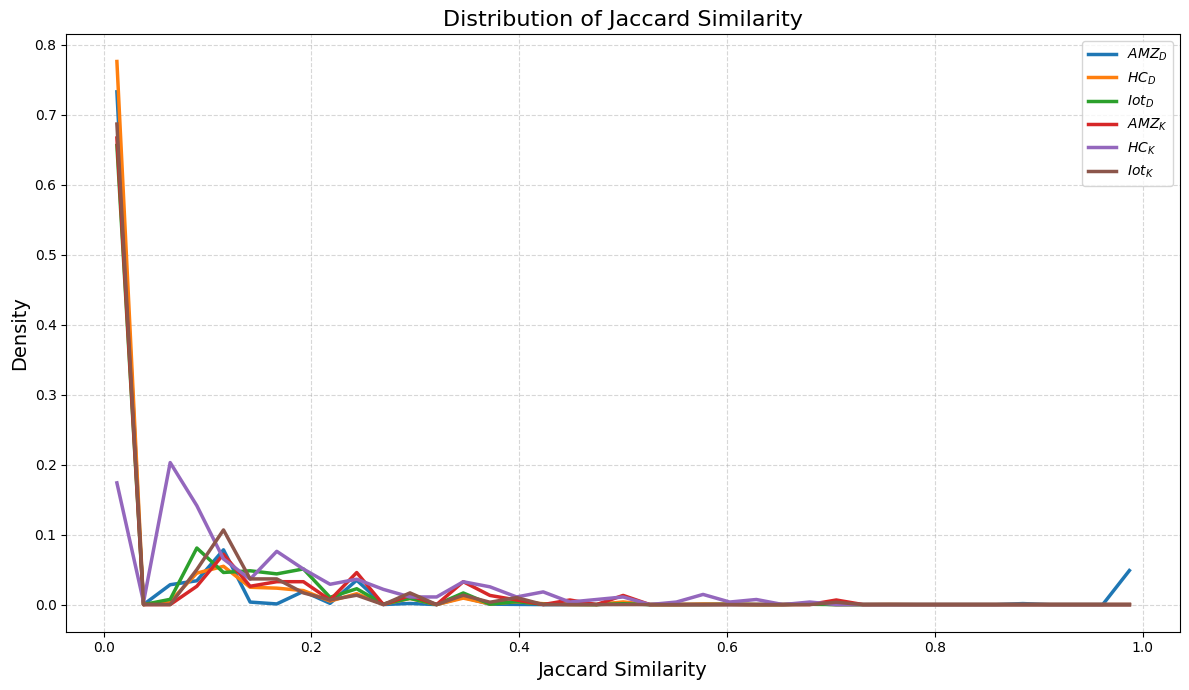

In [13]:
import ast
import itertools
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FILES
# ============================================================

files = [
    "reglas_abac.txt",
    "reglas_abac-hc.txt",
    "reglas_abac_iot.txt",
    "reglas_abac_karimi.txt",
    "reglas_abac_karimi_hc.txt",
    "reglas_abac_karimi_iot.txt",
]

labels = [
    r"$AMZ_{D}$",
    r"$HC_{D}$",
    r"$Iot_{D}$",
    r"$AMZ_{K}$",
    r"$HC_{K}$",
    r"$Iot_{K}$",
]

# ============================================================
# FUNCTION TO LOAD RULES
# ============================================================

def load_rules(filepath):

    rules = []

    with open(filepath, "r", encoding="utf-8") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            try:

                data = ast.literal_eval(line)

                attributes = data[1]

                # Convert rule into a set of attribute-value pairs
                rule = set()

                for attr, value in attributes:

                    rule.add((attr, value))

                rules.append(rule)

            except Exception as e:

                print(f"Error processing {filepath}")
                print(e)

    return rules

# ============================================================
# JACCARD SIMILARITY
# ============================================================

def jaccard_similarity(rule1, rule2):

    intersection = len(rule1.intersection(rule2))

    union = len(rule1.union(rule2))

    if union == 0:
        return 0

    return intersection / union

# ============================================================
# COMPUTE DISTRIBUTIONS
# ============================================================

all_similarities = []

for file in files:

    print(f"Processing {file}...")

    rules = load_rules(file)

    similarities = []

    # Pairwise comparisons
    for r1, r2 in itertools.combinations(rules, 2):

        sim = jaccard_similarity(r1, r2)

        similarities.append(sim)

    all_similarities.append(similarities)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(12, 7))

bins = np.linspace(0, 1, 40)

for similarities, label in zip(
    all_similarities,
    labels,
):

    # ========================================================
    # NORMALIZED HISTOGRAM
    # ========================================================

    hist, bin_edges = np.histogram(
        similarities,
        bins=bins
    )

    # Normalize frequencies
    hist = hist / hist.sum()

    # Bin centers
    x = (
        bin_edges[:-1] +
        bin_edges[1:]
    ) / 2
    plt.plot(
        x,
        hist,
        linewidth=2.5,
        linestyle='-',
        label=label
    )

# ============================================================
# STYLE
# ============================================================

plt.xlabel(
    "Jaccard Similarity",
    fontsize=14
)

plt.ylabel(
    "Density",
    fontsize=14
)

plt.title(
    "Distribution of Jaccard Similarity",
    fontsize=16
)

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.legend()

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "jaccard_similarity_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Processing reglas_abac_2.txt...
Processing reglas_abac_hc_2.txt...
Processing reglas_abac_iot_2.txt...
Processing reglas_abac_karimi_2.txt...
Processing reglas_abac_karimi_hc_2.txt...
Processing reglas_abac_karimi_iot_2.txt...


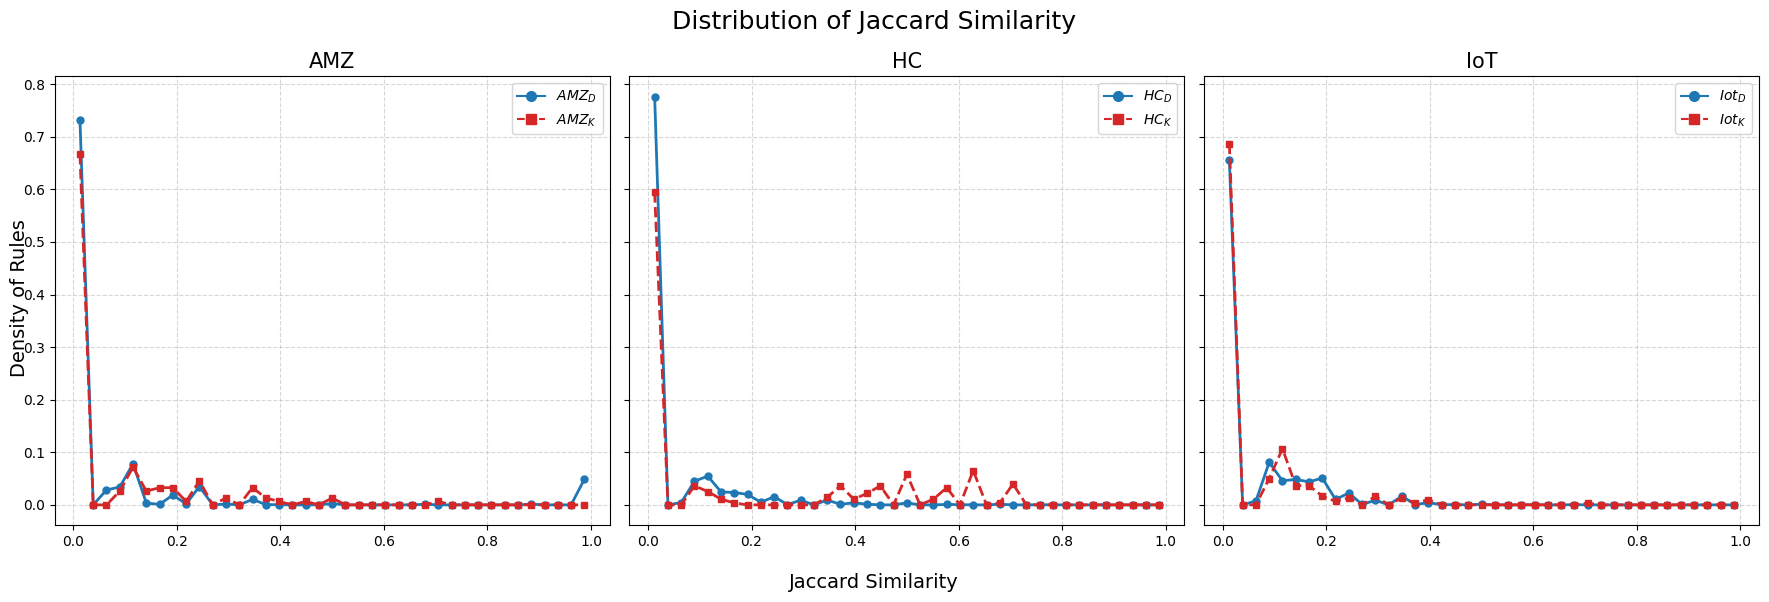

In [13]:
import ast
import itertools
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FILES
# ============================================================

files = [
    "reglas_abac.txt",
    "reglas_abac-hc.txt",
    "reglas_abac_iot.txt",
    "reglas_abac_karimi.txt",
    "reglas_abac_karimi_hc.txt",
    "reglas_abac_karimi_iot.txt",
]
files = [
    "reglas_abac_2.txt",
    "reglas_abac_hc_2.txt",
    "reglas_abac_iot_2.txt",
    "reglas_abac_karimi_2.txt",
    "reglas_abac_karimi_hc_2.txt",
    "reglas_abac_karimi_iot_2.txt",
]

labels = [
    r"$AMZ_{D}$",
    r"$HC_{D}$",
    r"$Iot_{D}$",
    r"$AMZ_{K}$",
    r"$HC_{K}$",
    r"$Iot_{K}$",
]

# ============================================================
# FUNCTION TO LOAD RULES
# ============================================================

def load_rules(filepath):

    rules = []

    with open(filepath, "r", encoding="utf-8") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            try:

                data = ast.literal_eval(line)

                attributes = data[1]

                # Rule as set of attribute-value pairs
                rule = set()

                for attr, value in attributes:

                    rule.add((attr, value))

                rules.append(rule)

            except Exception as e:

                print(f"Error processing {filepath}")
                print(e)

    return rules

# ============================================================
# JACCARD SIMILARITY
# ============================================================

def jaccard_similarity(rule1, rule2):

    intersection = len(
        rule1.intersection(rule2)
    )

    union = len(
        rule1.union(rule2)
    )

    if union == 0:
        return 0

    return intersection / union

# ============================================================
# COMPUTE DISTRIBUTIONS
# ============================================================

all_similarities = []

for file in files:

    print(f"Processing {file}...")

    rules = load_rules(file)

    similarities = []

    for r1, r2 in itertools.combinations(rules, 2):

        sim = jaccard_similarity(r1, r2)

        similarities.append(sim)

    all_similarities.append(similarities)

# ============================================================
# GROUPS
# ============================================================

groups = [
    (0, 3, "AMZ"),
    (1, 4, "HC"),
    (2, 5, "IoT")
]

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    sharey=True
)

bins = np.linspace(0, 1, 40)

# ============================================================
# PLOT
# ============================================================

for ax, (idx_d, idx_k, title) in zip(axes, groups):

    similarities_d = all_similarities[idx_d]
    similarities_k = all_similarities[idx_k]

    # ========================================================
    # NORMALIZED HISTOGRAM FOR D
    # ========================================================

    hist_d, bin_edges_d = np.histogram(
        similarities_d,
        bins=bins
    )

    hist_d = hist_d / hist_d.sum()

    x_d = (
        bin_edges_d[:-1] +
        bin_edges_d[1:]
    ) / 2

    # ========================================================
    # NORMALIZED HISTOGRAM FOR K
    # ========================================================

    hist_k, bin_edges_k = np.histogram(
        similarities_k,
        bins=bins
    )

    hist_k = hist_k / hist_k.sum()

    x_k = (
        bin_edges_k[:-1] +
        bin_edges_k[1:]
    ) / 2

    # ========================================================
    # STEM PLOT FOR D
    # ========================================================

    # ========================================================
    # PLOT FOR D
    # ========================================================

    ax.plot(
        x_d,
        hist_d,
        color='tab:blue',
        marker='o',
        markersize=5,
        linewidth=2
        #label=labels[idx_d]
    )

    # ========================================================
    # PLOT FOR K
    # ========================================================

    ax.plot(
        x_k,
        hist_k,
        color='tab:red',
        linestyle='--',
        marker='s',
        markersize=5,
        linewidth=2
        #label=labels[idx_k]
    )

    # ========================================================
    # TITLE
    # ========================================================

    ax.set_title(
        title,
        fontsize=15
    )

    # ========================================================
    # GRID
    # ========================================================

    ax.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

    # ========================================================
    # LEGEND
    # ========================================================

    ax.plot(
        [],
        [],
        marker='o',
        linestyle='-',
        color='tab:blue',
        markersize=7,
        label=labels[idx_d]
    )

    ax.plot(
        [],
        [],
        marker='s',
        linestyle='--',
        color='tab:red',
        markersize=7,
        label=labels[idx_k]
    )

    ax.legend()

# ============================================================
# GLOBAL LABELS
# ============================================================

fig.suptitle(
    "Distribution of Jaccard Similarity",
    fontsize=18
)

fig.supxlabel(
    "Jaccard Similarity",
    fontsize=14
)

fig.supylabel(
    "Density of Rules",
    fontsize=14
)

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "jaccard_similarity_subfigures.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [14]:
import ast
import numpy as np

# ============================================================
# FILES
# ============================================================

files = [
    "reglas_abac.txt",
    "reglas_abac-hc.txt",
    "reglas_abac_iot.txt",
    "reglas_abac_karimi.txt",
    "reglas_abac_karimi_hc.txt",
    "reglas_abac_karimi_iot.txt",
]

labels = [
    r"$AMZ_{D}$",
    r"$HC_{D}$",
    r"$Iot_{D}$",
    r"$AMZ_{K}$",
    r"$HC_{K}$",
    r"$Iot_{K}$",
]

# ============================================================
# FUNCTION TO LOAD RULES
# ============================================================

def load_rules(filepath):

    rules = []

    with open(filepath, "r", encoding="utf-8") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            try:

                data = ast.literal_eval(line)

                attributes = data[1]

                # Rule as set of attribute-value pairs
                rule = set()

                for attr, value in attributes:

                    rule.add((attr, value))

                rules.append(rule)

            except Exception as e:

                print(f"Error processing {filepath}")
                print(e)

    return rules

# ============================================================
# SUBSUMPTION RATIO
# ============================================================

def compute_subsumption_ratio(rules):

    n = len(rules)

    subsumed = []

    for i in range(n):

        ri = rules[i]

        is_subsumed = 0

        for j in range(n):

            if i == j:
                continue

            rj = rules[j]

            # ri subseteq rj
            if ri.issubset(rj):

                is_subsumed = 1
                break

        subsumed.append(is_subsumed)

    sub_ratio = np.mean(subsumed)

    total_subsumed = np.sum(subsumed)

    return sub_ratio, total_subsumed

# ============================================================
# COMPUTE METRICS
# ============================================================

results = []

for file, label in zip(files, labels):

    print(f"Processing {file}...")

    rules = load_rules(file)

    sub_ratio, total_subsumed = compute_subsumption_ratio(rules)

    results.append(
        (
            label,
            len(rules),
            total_subsumed,
            sub_ratio
        )
    )

# ============================================================
# GENERATE LATEX TABLE
# ============================================================

print("\n")

print(r"\begin{table}[ht]")
print(r"\centering")
print(r"\caption{Subsumption ratio statistics for each dataset.}")
print(r"\label{tab:subsumption_ratio}")
print(r"\begin{tabular}{lccc}")
print(r"\hline")
print(r"Dataset & $|R|$ & Subsumed Rules & $SubRatio(R)$ \\")
print(r"\hline")

for label, total_rules, total_subsumed, sub_ratio in results:

    print(
        f"{label} & "
        f"{total_rules} & "
        f"{total_subsumed} & "
        f"{sub_ratio:.4f} \\\\"
    )

print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")

Processing reglas_abac.txt...
Processing reglas_abac-hc.txt...
Processing reglas_abac_iot.txt...
Processing reglas_abac_karimi.txt...
Processing reglas_abac_karimi_hc.txt...
Processing reglas_abac_karimi_iot.txt...


\begin{table}[ht]
\centering
\caption{Subsumption ratio statistics for each dataset.}
\label{tab:subsumption_ratio}
\begin{tabular}{lccc}
\hline
Dataset & $|R|$ & Subsumed Rules & $SubRatio(R)$ \\
\hline
$AMZ_{D}$ & 156 & 123 & 0.7885 \\
$HC_{D}$ & 90 & 11 & 0.1222 \\
$Iot_{D}$ & 100 & 10 & 0.1000 \\
$AMZ_{K}$ & 18 & 1 & 0.0556 \\
$HC_{K}$ & 24 & 1 & 0.0417 \\
$Iot_{K}$ & 25 & 0 & 0.0000 \\
\hline
\end{tabular}
\end{table}


Processing reglas_abac.txt with train.csv
Processing reglas_abac-hc.txt with /Users/ddiaz/Documents/code/phd-thesis-lab/12-third_year/00-Data/02-HC/01-DistributionsCSV/HC-MOD.csv


/var/folders/g4/vgr09c9n7pd31lk61zpr3_440000gn/T/ipykernel_31729/442838057.py:97: DtypeWarning: Columns (1,2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(log_file)


Processing reglas_abac_iot.txt with /Users/ddiaz/Documents/code/phd-thesis-lab/12-third_year/00-Data/11-IoT/01-DistributionsCSV/IoT-Rw.csv
--> Tomando una muestra aleatoria del 10% para IoT-Rw.csv...
Processing reglas_abac_karimi.txt with train.csv
Processing reglas_abac_karimi_hc.txt with /Users/ddiaz/Documents/code/phd-thesis-lab/12-third_year/00-Data/02-HC/01-DistributionsCSV/HC-MOD.csv


/var/folders/g4/vgr09c9n7pd31lk61zpr3_440000gn/T/ipykernel_31729/442838057.py:97: DtypeWarning: Columns (1,2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(log_file)


Processing reglas_abac_karimi_iot.txt with /Users/ddiaz/Documents/code/phd-thesis-lab/12-third_year/00-Data/11-IoT/01-DistributionsCSV/IoT-Rw.csv
--> Tomando una muestra aleatoria del 10% para IoT-Rw.csv...


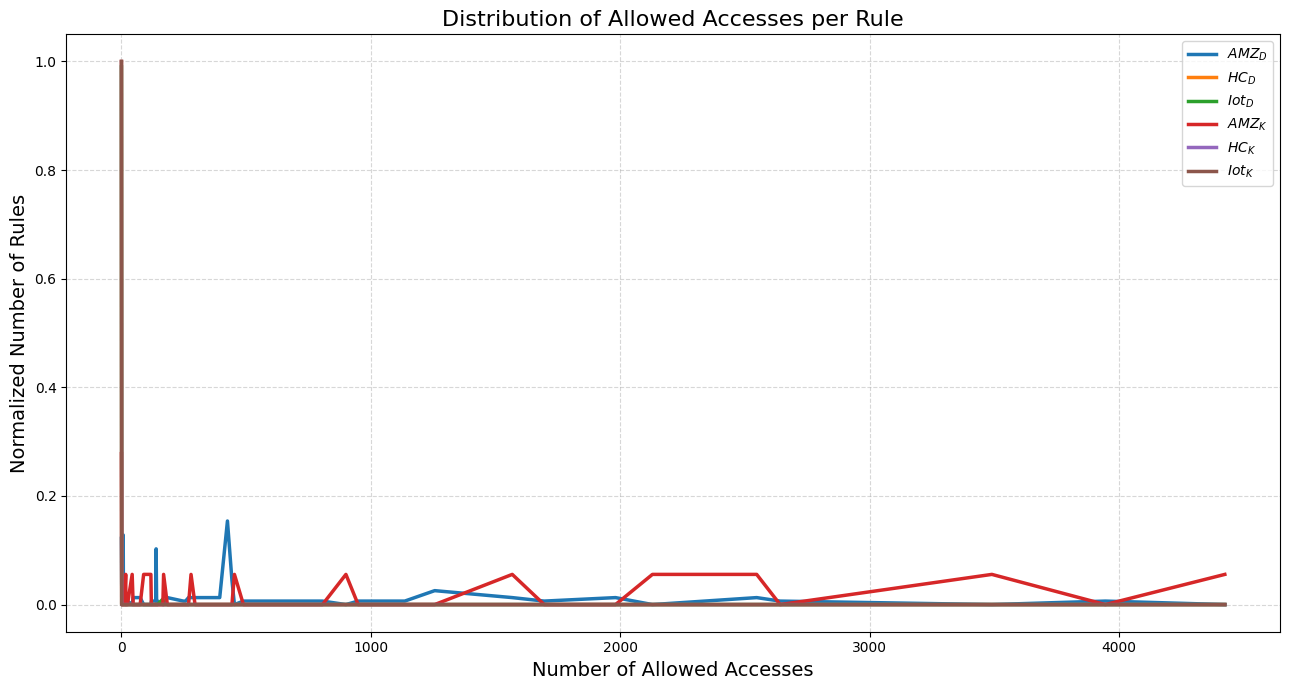

In [ ]:
import ast
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# RULE FILES
# ============================================================

rule_files = [
    "reglas_abac.txt",
    "reglas_abac-hc.txt",
    "reglas_abac_iot.txt",
    "reglas_abac_karimi.txt",
    "reglas_abac_karimi_hc.txt",
    "reglas_abac_karimi_iot.txt",
]

labels = [
    r"$AMZ_{D}$",
    r"$HC_{D}$",
    r"$Iot_{D}$",
    r"$AMZ_{K}$",
    r"$HC_{K}$",
    r"$Iot_{K}$",
]

# ============================================================
# ACCESS LOG FILES
# ============================================================

log_files = {
    "AMZ": "train.csv",
    "HC": "/Users/ddiaz/Documents/code/phd-thesis-lab/12-third_year/00-Data/02-HC/01-DistributionsCSV/HC-MOD.csv",
    "IoT": "/Users/ddiaz/Documents/code/phd-thesis-lab/12-third_year/00-Data/11-IoT/01-DistributionsCSV/IoT-Rw.csv"
}

# ============================================================
# LOAD RULES
# ============================================================

def load_rules(filepath):

    rules = []

    with open(filepath, "r", encoding="utf-8") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            try:

                data = ast.literal_eval(line)

                attributes = dict(data[1])

                rules.append(attributes)

            except Exception as e:

                print(f"Error processing {filepath}")
                print(e)

    return rules

# ============================================================
# RULE MATCHING
# ============================================================

def rule_matches(rule, access):

    for attr, value in rule.items():

        if attr not in access:
            return False

        if str(access[attr]) != str(value):
            return False

    return True

# ============================================================
# COUNT ACCESSES PER RULE
# ============================================================

def compute_access_distribution(rule_file, log_file):

    print(f"Processing {rule_file} with {log_file}")

    rules = load_rules(rule_file)

    df = pd.read_csv(log_file)
    
    # ========================================================
    # FILTRAR AL 10% SOLO SI ES EL DATASET DE IOT
    # ========================================================
    if log_file == log_files["IoT"]:
        print("--> Tomando una muestra aleatoria del 10% para IoT-Rw.csv...")
        df = df.sample(frac=0.05, random_state=42).reset_index(drop=True)

    access_counts = []

    # ========================================================
    # FOR EACH RULE COUNT MATCHING ACCESSES
    # ========================================================

    for rule in rules:

        count = 0

        for _, row in df.iterrows():

            access = row.to_dict()

            if rule_matches(rule, access):

                count += 1

        access_counts.append(count)

    # ========================================================
    # DISTRIBUTION
    # ========================================================

    distribution = Counter(access_counts)

    return distribution

# ============================================================
# MAP DATASETS TO LOGS
# ============================================================

dataset_logs = [
    log_files["AMZ"],
    log_files["HC"],
    log_files["IoT"],
    log_files["AMZ"],
    log_files["HC"],
    log_files["IoT"]
]

# ============================================================
# COMPUTE DISTRIBUTIONS
# ============================================================

all_distributions = []

for rule_file, log_file in zip(rule_files, dataset_logs):

    dist = compute_access_distribution(
        rule_file,
        log_file
    )

    all_distributions.append(dist)

# ============================================================
# GLOBAL X RANGE
# ============================================================

all_x = set()

for dist in all_distributions:

    all_x.update(dist.keys())

all_x = sorted(all_x)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(13, 7))

for dist, label in zip(all_distributions, labels):

    x = all_x

    y = [
        dist.get(v, 0)
        for v in x
    ]

    # Normalize frequencies
    y = np.array(y) / np.sum(y)

    plt.plot(
        x,
        y,
        linewidth=2.5,
        linestyle='-',
        label=label
    )

# ============================================================
# STYLE
# ============================================================

plt.xlabel(
    "Number of Allowed Accesses",
    fontsize=14
)

plt.ylabel(
    "Normalized Number of Rules",
    fontsize=14
)

plt.title(
    "Distribution of Allowed Accesses per Rule",
    fontsize=16
)

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.legend()

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "access_per_rule_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [1]:
import ast
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# RULE FILES
# ============================================================

rule_files = [
    "reglas_abac.txt",
    "reglas_abac-hc.txt",
    "reglas_abac_iot.txt",
    "reglas_abac_karimi.txt",
    "reglas_abac_karimi_hc.txt",
    "reglas_abac_karimi_iot.txt",
]

labels = [
    r"$AMZ_{D}$",
    r"$HC_{D}$",
    r"$Iot_{D}$",
    r"$AMZ_{K}$",
    r"$HC_{K}$",
    r"$Iot_{K}$",
]

# ============================================================
# ACCESS LOG FILES
# ============================================================

log_files = {
    "AMZ": "train.csv",
    "HC": "hc_al.csv",
    "IoT": "iot_al.csv"
}

# ============================================================
# LOAD RULES
# ============================================================

def load_rules(filepath):

    rules = []

    with open(filepath, "r", encoding="utf-8") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            try:

                data = ast.literal_eval(line)

                attributes = dict(data[1])

                rules.append(attributes)

            except Exception as e:

                print(f"Error processing {filepath}")
                print(e)

    return rules

# ============================================================
# RULE MATCHING
# ============================================================

def rule_matches(rule, access):

    for attr, value in rule.items():

        if attr not in access:
            return False

        if str(access[attr]) != str(value):
            return False

    return True

# ============================================================
# COUNT ACCESSES PER RULE
# ============================================================

def compute_access_distribution(rule_file, log_file):

    print(f"Processing {rule_file} with {log_file}")

    rules = load_rules(rule_file)

    df = pd.read_csv(log_file)

    # ========================================================
    # SAMPLE FOR IoT
    # ========================================================

    #if log_file == log_files["IoT"]:

    #    print("--> Using 5% sample for IoT")

    #    df = df.sample(
    #        frac=0.05,
    #        random_state=42
    #    ).reset_index(drop=True)

    access_counts = []

    # ========================================================
    # EACH RULE MAY COVER MULTIPLE ACCESSES
    # ========================================================

    for rule in rules:

        count = 0

        for _, row in df.iterrows():

            access = row.to_dict()

            # ====================================================
            # DO NOT STOP AT FIRST MATCH
            # ====================================================

            if rule_matches(rule, access):

                count += 1

        access_counts.append(count)

    # ========================================================
    # DISTRIBUTION
    # ========================================================

    distribution = Counter(access_counts)

    return distribution

# ============================================================
# MAP DATASETS TO LOGS
# ============================================================

dataset_logs = [
    log_files["AMZ"],
    log_files["HC"],
    log_files["IoT"],
    log_files["AMZ"],
    log_files["HC"],
    log_files["IoT"]
]

# ============================================================
# COMPUTE DISTRIBUTIONS
# ============================================================

all_distributions = []

for rule_file, log_file in zip(
    rule_files,
    dataset_logs
):

    dist = compute_access_distribution(
        rule_file,
        log_file
    )

    all_distributions.append(dist)

# ============================================================
# GROUPS
# ============================================================

groups = [
    (0, 3, "AMZ"),
    (1, 4, "HC"),
    (2, 5, "IoT")
]

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    sharey=True
)

# ============================================================
# PLOT
# ============================================================

for ax, (idx_d, idx_k, title) in zip(axes, groups):

    dist_d = all_distributions[idx_d]
    dist_k = all_distributions[idx_k]

    # ========================================================
    # GLOBAL X RANGE FOR SUBPLOT
    # ========================================================

    all_x = sorted(
        set(dist_d.keys()).union(
            set(dist_k.keys())
        )
    )

    # ========================================================
    # VALUES
    # ========================================================

    y_d = np.array([
        dist_d.get(v, 0)
        for v in all_x
    ])

    y_k = np.array([
        dist_k.get(v, 0)
        for v in all_x
    ])

    # ========================================================
    # NORMALIZATION
    # ========================================================

    y_d = y_d / y_d.sum()

    y_k = y_k / y_k.sum()

    # ========================================================
    # PLOT FOR D
    # ========================================================

    ax.plot(
        all_x,
        y_d,
        color='tab:blue',
        marker='o',
        markersize=5,
        linewidth=2,
        label=labels[idx_d]
    )

    # ========================================================
    # PLOT FOR K
    # ========================================================

    ax.plot(
        all_x,
        y_k,
        color='tab:red',
        marker='s',
        markersize=5,
        linewidth=2,
        label=labels[idx_k]
    )

    # ========================================================
    # TITLE
    # ========================================================

    ax.set_title(
        title,
        fontsize=15
    )

    # ========================================================
    # GRID
    # ========================================================

    ax.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

    # ========================================================
    # LEGEND
    # ========================================================

    ax.legend()

# ============================================================
# GLOBAL LABELS
# ============================================================

fig.suptitle(
    "Distribution of Allowed Accesses per Rule",
    fontsize=18
)

fig.supxlabel(
    "Number of Allowed Accesses",
    fontsize=14
)

fig.supylabel(
    "Normalized Number of Rules",
    fontsize=14
)

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "access_per_rule_distribution_subfigures.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Processing reglas_abac.txt with train.csv


KeyboardInterrupt: 

In [3]:
import ast
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# RULE FILES
# ============================================================

rule_files = [
    "reglas_abac.txt",
    "reglas_abac-hc.txt",
    "reglas_abac_iot.txt",
    "reglas_abac_karimi.txt",
    "reglas_abac_karimi_hc.txt",
    "reglas_abac_karimi_iot.txt",
]

labels = [
    r"$AMZ_{D}$",
    r"$HC_{D}$",
    r"$Iot_{D}$",
    r"$AMZ_{K}$",
    r"$HC_{K}$",
    r"$Iot_{K}$",
]

# ============================================================
# ACCESS LOG FILES
# ============================================================

log_files = {
    "AMZ": "train.csv",
    "HC": "hc_al.csv",
    "IoT": "iot_al.csv"
}

# ============================================================
# LOAD RULES
# ============================================================

def load_rules(filepath):

    rules = []

    with open(filepath, "r", encoding="utf-8") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            try:

                data = ast.literal_eval(line)

                attributes = dict(data[1])

                rules.append(attributes)

            except Exception as e:

                print(f"Error processing {filepath}")
                print(e)

    return rules

# ============================================================
# RULE MATCHING
# ============================================================

def rule_matches(rule, access):

    for attr, value in rule.items():

        if attr not in access:
            return False

        if str(access[attr]) != str(value):
            return False

    return True

# ============================================================
# COUNT ACCESSES PER RULE
# ============================================================

def compute_access_distribution(rule_file, log_file):

    print(f"Processing {rule_file} with {log_file}")

    rules = load_rules(rule_file)

    df = pd.read_csv(log_file)

    # ========================================================
    # SAMPLE FOR IoT
    # ========================================================

    #if log_file == log_files["IoT"]:

    #    print("--> Using 5% sample for IoT")

    #    df = df.sample(
    #        frac=0.05,
    #        random_state=42
    #    ).reset_index(drop=True)

    access_counts = []

    # ========================================================
    # EACH RULE MAY COVER MULTIPLE ACCESSES
    # ========================================================

    for rule in rules:

        count = 0

        for _, row in df.iterrows():

            access = row.to_dict()

            # ====================================================
            # DO NOT STOP AT FIRST MATCH
            # ====================================================

            if rule_matches(rule, access):

                count += 1

        access_counts.append(count)

    # ========================================================
    # DISTRIBUTION
    # ========================================================

    distribution = Counter(access_counts)

    return distribution

# ============================================================
# MAP DATASETS TO LOGS
# ============================================================

dataset_logs = [
    log_files["AMZ"],
    log_files["HC"],
    log_files["IoT"],
    log_files["AMZ"],
    log_files["HC"],
    log_files["IoT"]
]

# ============================================================
# COMPUTE DISTRIBUTIONS
# ============================================================

all_distributions = []

for rule_file, log_file in zip(
    rule_files,
    dataset_logs
):

    dist = compute_access_distribution(
        rule_file,
        log_file
    )

    all_distributions.append(dist)

# ============================================================
# GROUPS
# ============================================================

groups = [
    (0, 3, "AMZ"),
    (1, 4, "HC"),
    (2, 5, "IoT")
]


Processing reglas_abac.txt with train.csv
Processing reglas_abac-hc.txt with hc_al.csv
Processing reglas_abac_iot.txt with iot_al.csv
Processing reglas_abac_karimi.txt with train.csv
Processing reglas_abac_karimi_hc.txt with hc_al.csv
Processing reglas_abac_karimi_iot.txt with iot_al.csv


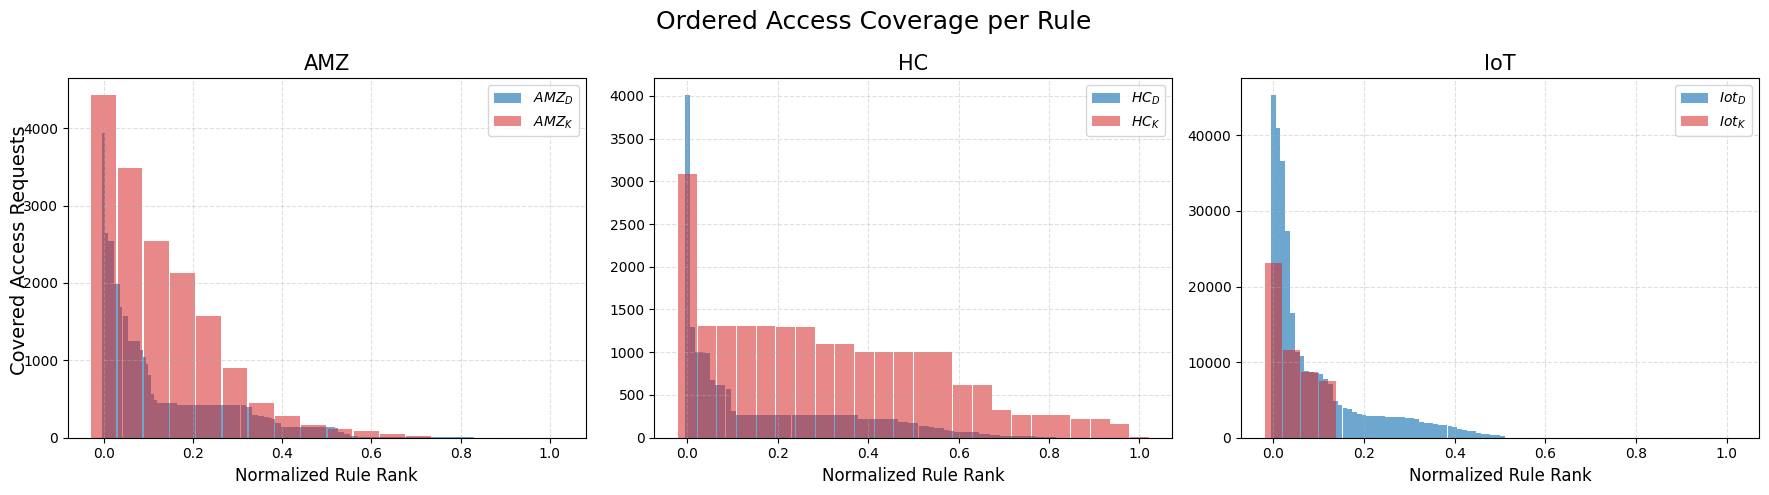

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# SORTED COVERAGE BAR PLOTS
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharey=False
)

# ============================================================
# DATASET GROUPS
# ============================================================

groups = [
    (0, 3, "AMZ"),
    (1, 4, "HC"),
    (2, 5, "IoT")
]

# ============================================================
# COLORS
# ============================================================

color_d = "tab:blue"
color_k = "tab:red"

# ============================================================
# PLOTS
# ============================================================

for ax, (idx_d, idx_k, title) in zip(axes, groups):

    # ========================================================
    # LOAD DISTRIBUTIONS
    # ========================================================

    dist_d = all_distributions[idx_d]
    dist_k = all_distributions[idx_k]

    # ========================================================
    # EXPAND DISTRIBUTIONS
    # ========================================================

    accesses_d = []

    for access_count, freq in dist_d.items():

        accesses_d.extend([access_count] * freq)

    accesses_k = []

    for access_count, freq in dist_k.items():

        accesses_k.extend([access_count] * freq)

    # ========================================================
    # SORT DESCENDING
    # ========================================================

    accesses_d = sorted(accesses_d, reverse=True)
    accesses_k = sorted(accesses_k, reverse=True)

    # ========================================================
    # NORMALIZED X AXIS
    # ========================================================

    x_d = np.linspace(0, 1, len(accesses_d))
    x_k = np.linspace(0, 1, len(accesses_k))

    # ========================================================
    # BAR WIDTHS
    # ========================================================

    width_d = 1 / len(accesses_d)
    width_k = 1 / len(accesses_k)

    # ========================================================
    # BARS
    # ========================================================

    ax.bar(
        x_d,
        accesses_d,
        width=width_d,
        alpha=0.65,
        color=color_d,
        label=labels[idx_d]
    )

    ax.bar(
        x_k,
        accesses_k,
        width=width_k,
        alpha=0.55,
        color=color_k,
        label=labels[idx_k]
    )

    # ========================================================
    # TITLES
    # ========================================================

    ax.set_title(
        title,
        fontsize=15
    )

    # ========================================================
    # AXES
    # ========================================================

    ax.set_xlabel(
        "Normalized Rule Rank",
        fontsize=12
    )

    # ========================================================
    # GRID
    # ========================================================

    ax.grid(
        linestyle='--',
        alpha=0.4
    )

    local_max = max(
        max(accesses_d),
        max(accesses_k)
    )

    ax.set_ylim(
        0,
        local_max * 1.05
    )

    # ========================================================
    # LEGEND
    # ========================================================

    ax.legend()

# ============================================================
# GLOBAL LABELS
# ============================================================

fig.suptitle(
    "Ordered Access Coverage per Rule",
    fontsize=18
)

fig.supylabel(
    "Covered Access Requests",
    fontsize=14
)

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "ordered_rule_coverage.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()